In [1]:
import keras
from keras import Sequential, Input, layers, regularizers
from keras.metrics import AUC
import pandas as pd

2025-11-21 18:19:30.288780: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-21 18:19:30.292858: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-21 18:19:30.851650: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-21 18:19:36.776092: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
from predicting_loan.ml_logic.data import SimpleMissingHandler, load_data
from predicting_loan.ml_logic.preprocessor import preprocess_data
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [3]:
df = load_data("../raw_data/Loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
handler = SimpleMissingHandler(how="auto")
df_fixed = handler.fix_missing(df)

# TARGET + DROP USELESS COLUMNS
df = df.drop(columns=["LoanID"])     # ID column not useful
print (df_fixed.head())


X = df.drop(columns=["Default"])
y = df["Default"]

       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      Divorced         Yes           Yes       Other   
1      Full-time    

In [5]:
X.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No


In [6]:
from colorama import Fore, Style
import numpy as np

In [7]:
values, counts = np.unique(y, return_counts=True)
values, counts, counts / counts.sum()

(array([0, 1]), array([225694,  29653]), array([0.88387175, 0.11612825]))

In [8]:
def preprocess_features(X: pd.DataFrame) -> np.ndarray:

    print(Fore.BLUE + "\nPreprocessing features..." + Style.RESET_ALL)

    preprocessor = preprocess_data(df_fixed)
    X_processed = preprocessor.fit_transform(X)

    print("✅ X_processed, with shape", X_processed.shape)

    return X_processed

X_processed = preprocess_features(X)


Preprocessing features...
✅ X_processed, with shape (255347, 28)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.25, random_state=42, stratify=y
)

In [10]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((191510, 28), (63837, 28), (191510,), (63837,))

In [11]:
reg_l1 = regularizers.L1(0.01)
reg_l2 = regularizers.L2(0.01)
reg_l1_l2 = regularizers.l1_l2(l1=0.005, l2=0.0005)

E0000 00:00:1763745584.873531   42972 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1763745584.880842   42972 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [42]:
def initialize_model():
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(layers.Dense(32, activation='relu', kernel_regularizer=reg_l1))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy',
                           AUC(name='roc_auc')])
    return model

model = initialize_model()

In [32]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,017 (7.88 KB)

 Trainable params: 2,017 (7.88 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
parameters = model.count_params()
print(f'The model has {parameters} parameters.')

The model has 2017 parameters.


In [34]:
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,-0.034751,0.347735,0.516667,0.900700,0.054975,0.914230,0.908503,2.0,3.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.593366,0.901627,-0.216667,1.434381,-0.284854,-1.559991,0.128999,3.0,3.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.272341,0.682461,-0.083333,-0.700343,-0.184164,-1.255611,-1.256785,2.0,3.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.956368,-0.689113,-0.766667,1.634511,-1.461669,-0.877395,-0.000918,0.0,3.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.474823,-0.073395,0.816667,-0.033242,0.394803,0.941353,-0.693811,0.0,2.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [35]:
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    confusion_matrix, RocCurveDisplay, roc_auc_score
)
from keras.callbacks import EarlyStopping

In [43]:
es = EarlyStopping(patience=20,
                   monitor='val_loss',
                   restore_best_weights=True)

# FIT MODEL
model.fit(X_train,
          y_train,
          epochs=8,
          batch_size=32,
          verbose=1,
          validation_split=0.2,
          callbacks=[es])
results = {}

# PREDICTIONS PROBA
y_proba = model.predict(X_test).ravel()
# CLASS PREDICTIONS
y_pred = (y_proba >= 0.188).astype(int)

# METRICS
results['Neural Network'] = {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}

Epoch 1/8
4788/4788 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8828 - loss: 0.3823 - roc_auc: 0.7220 - val_accuracy: 0.8860 - val_loss: 0.3313 - val_roc_auc: 0.7375
Epoch 2/8
4788/4788 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8835 - loss: 0.3298 - roc_auc: 0.7368 - val_accuracy: 0.8875 - val_loss: 0.3223 - val_roc_auc: 0.7436
Epoch 3/8
4788/4788 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8841 - loss: 0.3278 - roc_auc: 0.7383 - val_accuracy: 0.8878 - val_loss: 0.3214 - val_roc_auc: 0.7414
Epoch 4/8
4788/4788 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8838 - loss: 0.3270 - roc_auc: 0.7388 - val_accuracy: 0.8876 - val_loss: 0.3205 - val_roc_auc: 0.7421
Epoch 5/8
4788/4788 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8841 - loss: 0.3269 - roc_auc: 0.7381 - val_accuracy: 0.8869 - val_loss: 0.3202 - val_roc_auc: 0.7421
Epoch 6/8
4788/4788 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8843 - loss: 0.3268 - roc_auc: 0.7383 - val_accuracy: 0.8871 - val_loss: 0.3216 - val_ro

In [44]:
history = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss: {history[0]}, Test Accuracy: {history[1]}')

Test Loss: 0.32106393575668335, Test Accuracy: 0.8851919770240784


In [45]:
results['Neural Network']

{'accuracy': 0.817127997869574,
 'f1': 0.3596269884805266,
 'recall': 0.4421961419128558,
 'precision': 0.3030415087362485,
 'roc_auc': 0.7513704018364051}

In [20]:
y_pred = model.predict(X_test)

results_df = pd.DataFrame(y_pred, columns=['y_pred'])
results_df.head()

1995/1995 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step


,y_pred
0,0.115796
1,0.115796
2,0.115796
3,0.115796
4,0.115796


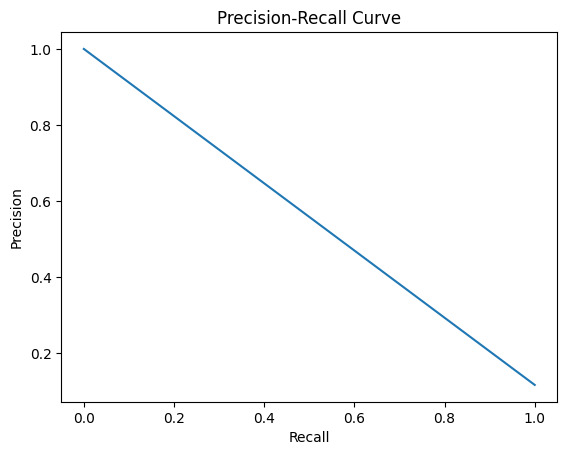

In [21]:
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Plot
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [22]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# precision/recall have length = len(thresholds) + 1
# We drop the last point (it has no corresponding threshold)
precision = precision[:-1]
recall = recall[:-1]

f1_scores = 2 * (precision * recall) / (precision + recall)

# Replace NaNs (from 0/0) with 0 so they don't win argmax
f1_scores = np.nan_to_num(f1_scores, nan=0.0)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.11579577
Best F1: 0.2080842105263158


In [23]:
y_pred_opt = (y_proba >= best_threshold).astype(int)

from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred_opt))
print("Recall   :", recall_score(y_test, y_pred_opt))
print("F1       :", f1_score(y_test, y_pred_opt))

Precision: 0.1161238780017858
Recall   : 1.0
F1       : 0.2080842105263158
